# Análisis Exploratorio de los Datos

### Importación de librerías

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
palette = {"Control": "#2ecc71", "Prodromal": "#f1c40f", "PD": "#e74c3c"}

ruta_pd_control = Path("../../data/indexs/ppmi_pd_control.csv")
ruta_prodromal = Path("../../data/indexs/ppmi_prodromal.csv")

df_raw = pd.concat([pd.read_csv(ruta_pd_control), pd.read_csv(ruta_prodromal)], ignore_index=True)

df_raw['Group'] = df_raw['Group'].astype(str).str.strip()

columna_fabricante = 'Manufacturer' if 'Manufacturer' in df_raw.columns else 'Mfg'
if columna_fabricante in df_raw.columns:
    df_raw[columna_fabricante] = df_raw[columna_fabricante].fillna('Desconocido').astype(str).str.strip()

df_pacientes = df_raw.sort_values(by=['Subject', 'Age']).drop_duplicates(subset=['Subject'], keep='first').copy()

### Balanceo de datos

#### Clases

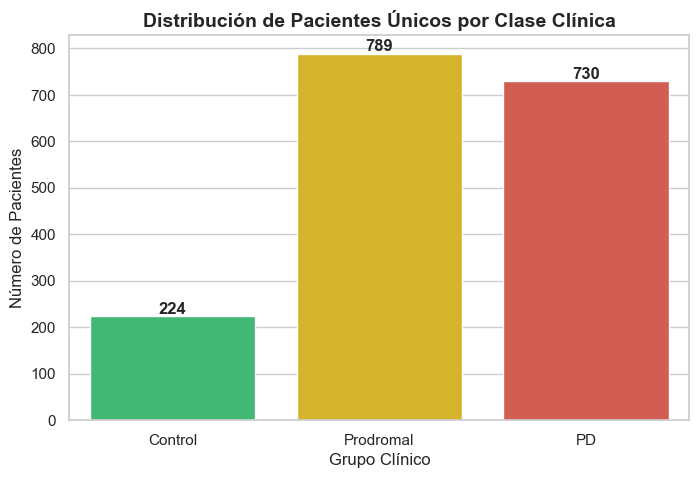

In [35]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df_pacientes, x='Group', hue='Group', palette=palette, order=['Control', 'Prodromal', 'PD'], legend=False)

plt.title('Distribución de Pacientes Únicos por Clase Clínica', fontweight='bold', fontsize=14)
plt.ylabel('Número de Pacientes')
plt.xlabel('Grupo Clínico')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()

#### Rango edades

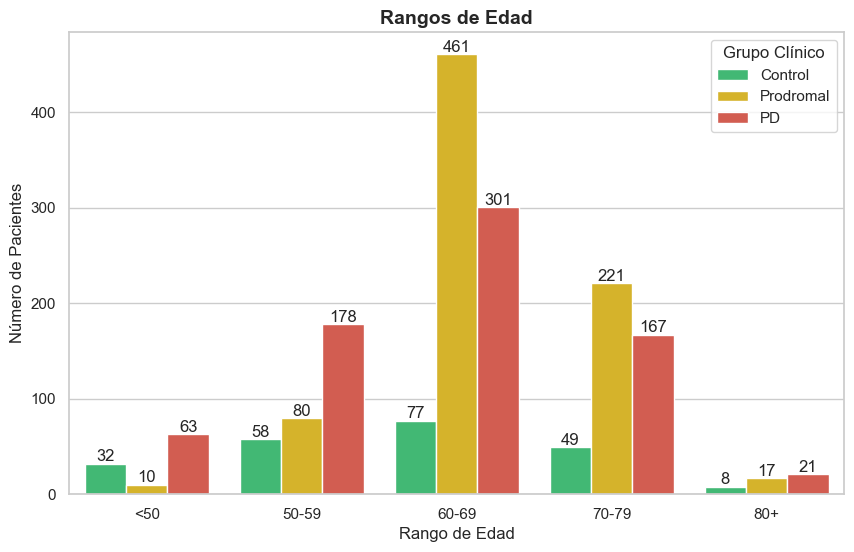

In [36]:
bins = [0, 50, 60, 70, 80, 120]
labels = ['<50', '50-59', '60-69', '70-79', '80+']
df_pacientes['Age_Group'] = pd.cut(df_pacientes['Age'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_pacientes, x='Age_Group', hue='Group', palette=palette, 
                   hue_order=['Control', 'Prodromal', 'PD'])

plt.title('Rangos de Edad', fontweight='bold', fontsize=14)
plt.ylabel('Número de Pacientes')
plt.xlabel('Rango de Edad')

for p in ax.patches:
    if pd.notnull(p.get_height()) and p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.legend(title='Grupo Clínico')
plt.show()

#### Sexos

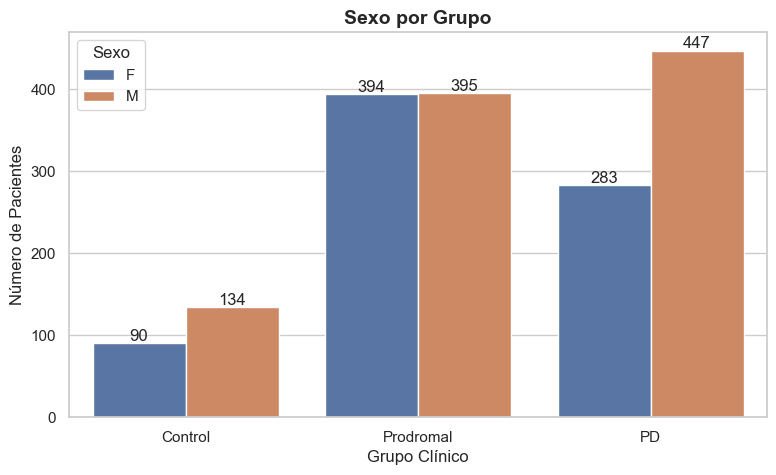

In [37]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df_pacientes, x='Group', hue='Sex', order=['Control', 'Prodromal', 'PD'])

plt.title('Sexo por Grupo', fontweight='bold', fontsize=14)
plt.ylabel('Número de Pacientes')
plt.xlabel('Grupo Clínico')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.legend(title='Sexo')
plt.show()

#### Valores nulos o faltantes

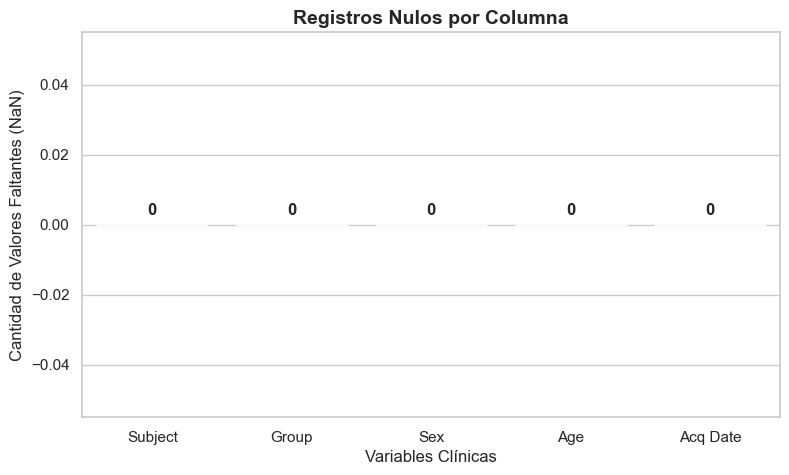

In [38]:
columnas_clave = ['Subject', 'Group', 'Sex', 'Age', 'Acq Date']
nulos = df_pacientes[columnas_clave].isnull().sum()

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=nulos.index, y=nulos.values, hue=nulos.index, palette='viridis', legend=False)

plt.title('Registros Nulos por Columna', fontweight='bold', fontsize=14)
plt.ylabel('Cantidad de Valores Faltantes (NaN)')
plt.xlabel('Variables Clínicas')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.show()